# Per-litter allele frequency boxplots — PRE / POST / END

Interactive version of `make_per_litter_boxplots.py`, for looking at the figure and tweaking its appearance.

**The figure:** 6 panels — rows = diet (HF / LF), columns = timepoint. One box per litter inside each panel, shared y-axis and identical litter ordering throughout.

**Each box** holds one value per site: the mean anchor-allele frequency across that litter's mice for that diet at that timepoint.

**TruSeq only / 8 litters.** Only `pre`/`post`/`end` rows are read. Hackflex samples are labelled `T0`-`T14` and drop out. Replicate 3 has no TruSeq samples at all — its sampling stops at day 33 while `end` spans days 79-153 — so 8 litters remain. Nothing is excluded by hand.

**Caveat to carry with the figure.** The anchor allele is the nucleotide that rose most in the *fat* mice from pre to end, and candidate sites come from the fat-vs-control paired pre→end test. A rise in the HF panels is partly built in by construction; the LF panels and consistency across litters carry the real information.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

LONG_TABLE = (
    "/scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/AlleleFlux_revision/"
    "plotting_SLG443_DASTool_bins_SLG443_bin.96_final/track_freqs/"
    "SLG443_DASTool_bins_SLG443_bin.96_frequency_table.long.tsv"
)
OUTPUT_DIR = Path("figures")

TIMEPOINTS = ["pre", "post", "end"]
GROUP_LABELS = {"fat": "HF", "control": "LF"}
GROUP_ORDER = ["fat", "control"]  # HF on top

NEEDED_COLS = [
    "contig", "position", "anchor_allele", "min_p_value",
    "frequency", "group", "time", "subjectID", "replicate",
]

# --- Panel colors -------------------------------------------------------------
# One fill color per (diet, timepoint), i.e. one per panel. Hex values are
# eyeballed from the reference figure - swap them freely.
PANEL_COLORS = {
    ("fat",     "pre"):  "#00A087",   # teal
    ("control", "pre"):  "#EFC000",   # gold
    ("fat",     "post"): "#6A8CC7",   # blue
    ("control", "post"): "#E8368F",   # magenta
    ("fat",     "end"):  "#5D4E9E",   # purple
    ("control", "end"):  "#EE7A22",   # orange
}
# Fallback if a (group, timepoint) pair is missing from the dict above.
DEFAULT_COLOR = "#888888"

# --- Violin width normalization -----------------------------------------------
# Applies to kind="violin" only. Change this and re-run the plotting cell.
#   "width" : every violin drawn the same width. Hides the fact that some boxes
#             hold far fewer sites than others (1,043 vs 2,000 at n=2000).
#   "count" : width scales with the number of sites behind it, so thin violins
#             signal weaker support. More honest given the coverage gaps.
#   "area"  : equal area per violin.
DENSITY_NORM = "width"


## 1. Load only the TruSeq rows

The table is ~5.2 GB, but only ~20% of rows and 9 of 15 columns are needed. Reading in chunks and filtering as we go keeps peak memory near 1-2 GB instead of ~14 GB. Takes a few minutes.

In [2]:
kept, total = [], 0
for chunk in pd.read_csv(LONG_TABLE, sep="\t", usecols=NEEDED_COLS, chunksize=2_000_000):
    total += len(chunk)
    kept.append(chunk[chunk["time"].isin(TIMEPOINTS)])
    print(f"  scanned {total:,} rows...", end="\r")

df = pd.concat(kept, ignore_index=True)
del kept

for col in ("contig", "anchor_allele", "group", "time"):
    df[col] = df[col].astype("category")

print(f"\nkept {len(df):,} of {total:,} rows ({len(df)/total:.1%})")
print(f"litters : {sorted(df['replicate'].unique())}")
print(f"times   : {sorted(df['time'].unique())}")
print(f"mice    : {df['subjectID'].nunique()}")
print(f"memory  : {df.memory_usage(deep=True).sum()/1e9:.2f} GB")

  scanned 23,350,849 rows...
kept 4,787,190 of 23,350,849 rows (20.5%)
litters : [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
times   : ['end', 'post', 'pre']
mice    : 30
memory  : 0.22 GB


## 2. Average each litter's mice per site

One value per (site, litter, diet, timepoint). `n_mice` records how many mice backed each mean — litter 2 has only one per diet.

In [3]:
means = df.groupby(
    ["time", "group", "replicate", "contig", "position", "anchor_allele"],
    observed=True, as_index=False,
).agg(
    frequency=("frequency", "mean"),
    n_mice=("subjectID", "nunique"),   # mice PRESENT as rows -- includes ones with no coverage
    n_valid=("frequency", "count"),    # mice that actually contributed a number (.count() skips NaN)
)

print(f"{len(means):,} litter-mean values")

# 12% of TruSeq frequencies are NaN: the table is a complete site x sample grid, but a
# sample with too little coverage at a site carries no value. Two consequences:
#   - mean() skips NaN, so a "litter mean" can rest on one mouse even where both are present
#   - if BOTH mice are missing the mean is NaN and seaborn drops that site from the box
#     silently, so boxes do not all contain the same number of sites
print(f"  mean is NaN (no mouse had coverage)   : "
      f"{means['frequency'].isna().sum():,} ({means['frequency'].isna().mean():.1%})")
print(f"  n_mice=2 but only 1 mouse had coverage: "
      f"{((means['n_mice'] == 2) & (means['n_valid'] == 1)).sum():,}")

# Use n_valid, NOT n_mice, for any "how much data backs this" question.
means.groupby(["time", "group", "replicate"], observed=True)["n_valid"].max().unstack("replicate")

2,553,168 litter-mean values
  mean is NaN (no mouse had coverage)   : 98,295 (3.8%)
  n_mice=2 but only 1 mouse had coverage: 410,507


replicate     1  2  4  5  6  7  8  9
time group                          
end  control  2  1  2  2  2  2  2  2
     fat      2  1  2  2  2  2  2  2
post control  2  1  2  2  2  2  2  2
     fat      2  1  2  2  2  2  2  2
pre  control  2  1  2  2  2  2  2  2
     fat      2  1  2  2  2  2  2  2

### How many sites actually land in each box?

Selection puts the same site set in every panel, but coverage does not: a site whose two mice
both lack coverage has a NaN mean and is dropped from that box. So box sizes differ — worth
knowing before reading a low box as biology.

In [4]:
(means.dropna(subset=["frequency"])
      .groupby(["group", "time", "replicate"], observed=True)
      .size().rename("n_sites")
      .reset_index()
      .pivot_table(index=["group", "time"], columns="replicate", values="n_sites"))

/tmp/ipykernel_180476/1008958603.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index=["group", "time"], columns="replicate", values="n_sites"))


replicate           1        2        4        5        6        7        8  \
group   time                                                                  
control end   53191.0  53157.0  53191.0  53191.0  53141.0  53191.0  53189.0   
        post  53181.0  45970.0  53155.0  53191.0  53161.0  53185.0  53182.0   
        pre   53185.0  52240.0  53191.0  53190.0  53184.0  53175.0  53128.0   
fat     end   51655.0  53186.0  53178.0  52579.0  53118.0  52240.0  53135.0   
        post  53189.0  52873.0  52549.0  53165.0  52266.0  41511.0  38367.0   
        pre   53191.0  30730.0  53191.0  53190.0  53181.0  53189.0  39818.0   

replicate           9  
group   time           
control end   53101.0  
        post  53191.0  
        pre   52682.0  
fat     end   52747.0  
        post  41125.0  
        pre   43957.0

## 3. Plotting functions

`draw_panel` is the single place deciding how a panel is rendered — edit it to add a style.
`make_figure(means, df, n, ...)` keeps its original signature, plus toggles:

| toggle | options | note |
|---|---|---|
| `kind` | `"box"`, `"violin"`, `"boxen"`, `"strip"` | how each litter is drawn |
| `show_outliers` | `True` / `False` | box and boxen only |
| `show_mean` | `True` / `False` | red dot at each litter's mean |
| `n` | `"all"` or an integer | sites ranked by `min_p_value` |
| `save` | `True` / `False` | writes to `figures/` |
| `density_norm` | `"width"`, `"count"`, `"area"` | violin only; defaults to `DENSITY_NORM` |

Colors come from `PANEL_COLORS` in the setup cell — one per (diet, timepoint), so each of the
six panels has its own fill. Change a hex there and re-run this cell plus a plot cell.

`boxen` (letter-value) is often the sweet spot here: it shows tail structure without the
tens of thousands of outlier dots a plain boxplot draws.

In [9]:
def draw_panel(ax, cell, litters, color, kind, show_outliers, density_norm="width"):
    """Render one panel. Add new styles here.

    saturation=1 matters: seaborn mutes fills to 75%% saturation by default, so without
    it the exact hex codes in PANEL_COLORS are not what ends up on the page.
    """
    common = dict(data=cell, x="replicate", y="frequency", order=litters, ax=ax)

    if kind == "box":
        sns.boxplot(**common, color=color, saturation=1, showfliers=show_outliers,
                    fliersize=1)
    elif kind == "violin":
        # cut=0 stops the density extending past the observed data
        sns.violinplot(**common, color=color, saturation=1, cut=0, inner="box",
                       density_norm=density_norm)
    elif kind == "boxen":
        sns.boxenplot(**common, color=color, saturation=1, showfliers=show_outliers)
    elif kind == "strip":
        sns.stripplot(**common, color=color, size=1, alpha=0.2, jitter=0.25)
    else:
        raise ValueError(f"unknown kind: {kind!r}")


def make_figure(means, df, n, kind="box", show_outliers=True, save=True,
                output_format="pdf", ylim=(-0.05, 1.05), density_norm=None):
    # None -> fall back to DENSITY_NORM from the setup cell, so it can be changed
    # there without re-running this definition.
    density_norm = DENSITY_NORM if density_norm is None else density_norm

    sites = df[["contig", "position", "anchor_allele", "min_p_value"]].drop_duplicates()
    if str(n).lower() == "all":
        n_label = "ALL"
    else:
        sites, n_label = sites.nsmallest(int(n), "min_p_value"), str(n)

    # Inner join = the site filter. A no-op when n="all" (sites is every key in df),
    # but for a top-N run this is what restricts means to the selected sites. A left
    # join would keep everything, since only key columns are being merged.
    plot_df = means.merge(
        sites[["contig", "position", "anchor_allele"]],
        on=["contig", "position", "anchor_allele"], how="inner",
    )

    litters = sorted(plot_df["replicate"].unique())
    groups = [g for g in GROUP_ORDER if g in set(plot_df["group"])]
    print(f"n={n_label}: {len(sites):,} sites, {len(litters)} litters, {len(plot_df):,} values")

    sns.set_theme(style="whitegrid", context="talk")

    fig, axes = plt.subplots(
        nrows=len(groups), ncols=len(TIMEPOINTS),
        figsize=(6 * len(TIMEPOINTS), 5 * len(groups)),
        sharey=True, sharex=True, squeeze=False,
    )

    for row, group in enumerate(groups):
        for col, tp in enumerate(TIMEPOINTS):
            ax = axes[row][col]
            cell = plot_df[(plot_df["group"] == group) & (plot_df["time"] == tp)]
            color = PANEL_COLORS.get((group, tp), DEFAULT_COLOR)

            if cell.empty:
                ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            else:
                draw_panel(ax, cell, litters, color, kind, show_outliers, density_norm)

            ax.set_title(f"{GROUP_LABELS.get(group, group)} — {tp.upper()}")
            ax.set_ylim(*ylim)
            ax.set_xlabel("litter" if row == len(groups) - 1 else "")
            ax.set_ylabel("Mean allele frequency" if col == 0 else "")

    hidden = not show_outliers and kind not in {"violin", "strip"}
    norm_note = f", density_norm={density_norm}" if kind == "violin" else ""
    fig.suptitle(
        f"Anchor allele frequency by litter — N={n_label} sites — {kind}"
        + (", outliers hidden" if hidden else "") + norm_note
    )
    fig.tight_layout()

    if save:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        suffix = "_nofliers" if hidden else ""
        # keep the normalization in the filename so a width/count pair cannot
        # silently overwrite one another
        if kind == "violin" and density_norm != "width":
            suffix += f"_{density_norm}"
        out = OUTPUT_DIR / f"per_litter_{kind}_n{n_label}{suffix}.{output_format}"
        fig.savefig(out, dpi=300, bbox_inches="tight", format=output_format)
        print(f"[saved] {out}")
    return fig

n=ALL: 53,191 sites, 8 litters, 2,553,168 values
[saved] figures/per_litter_box_nALL.pdf


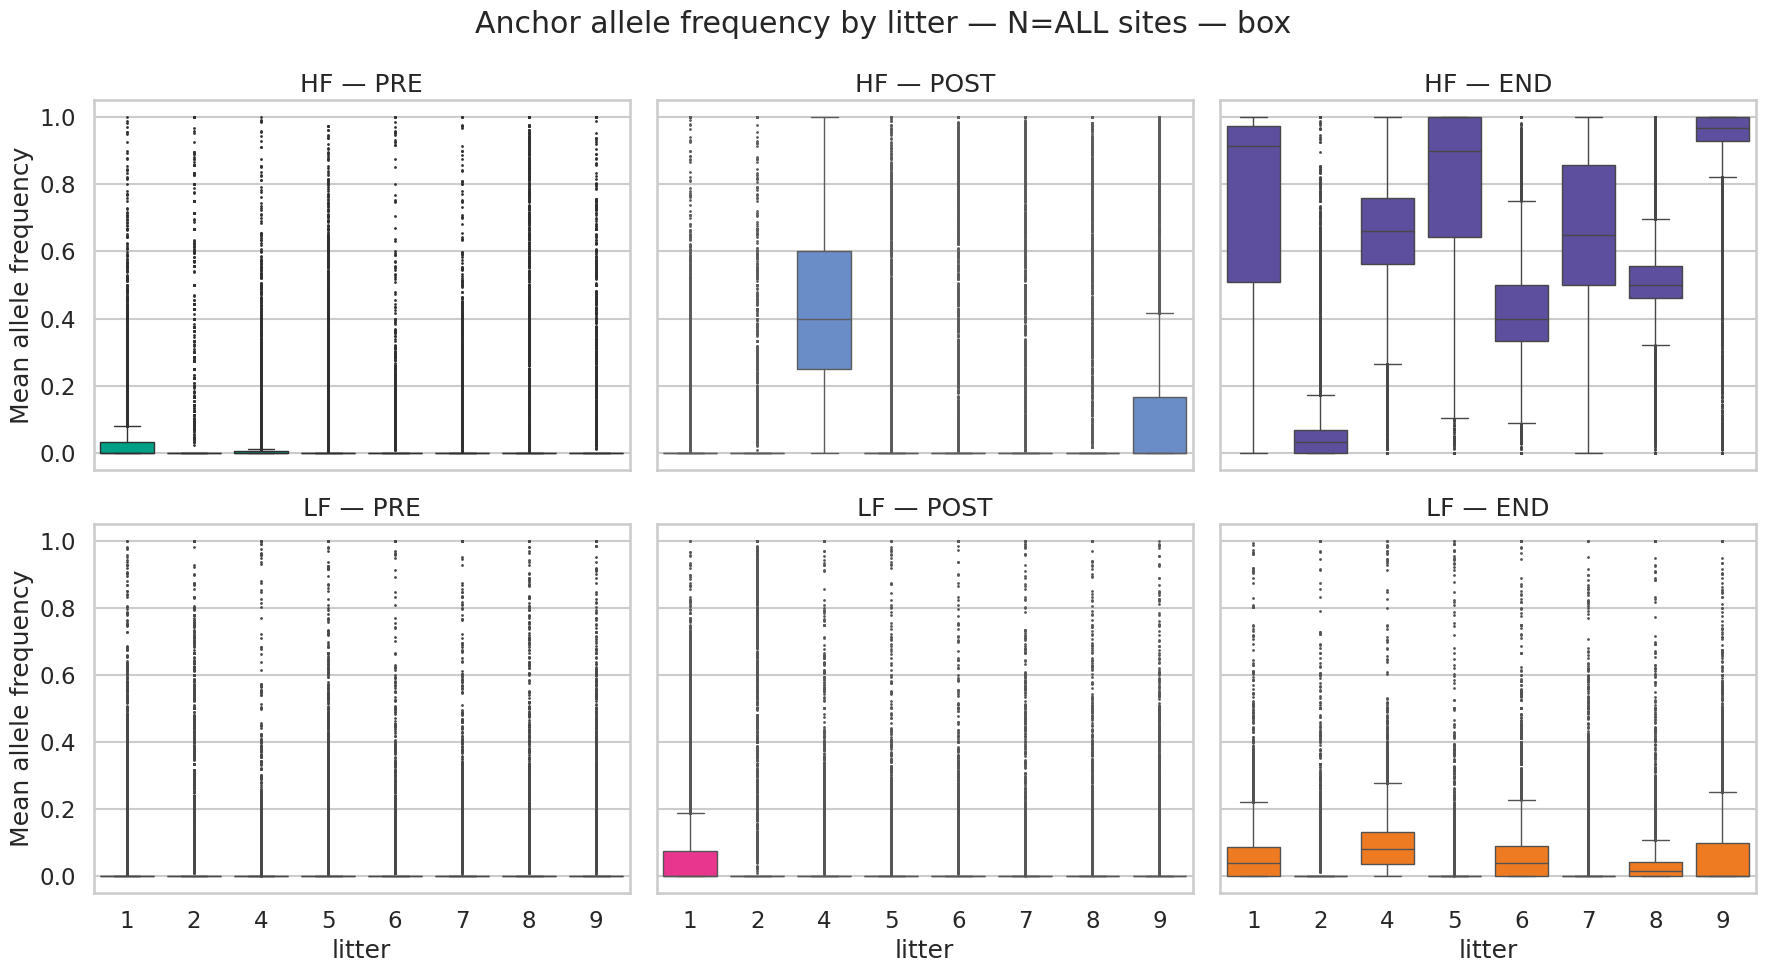

In [10]:
make_figure(means, df, "all", show_outliers=True, save=True)
plt.show()

n=ALL: 53,191 sites, 8 litters, 2,553,168 values
[saved] figures/per_litter_box_nALL_nofliers.pdf


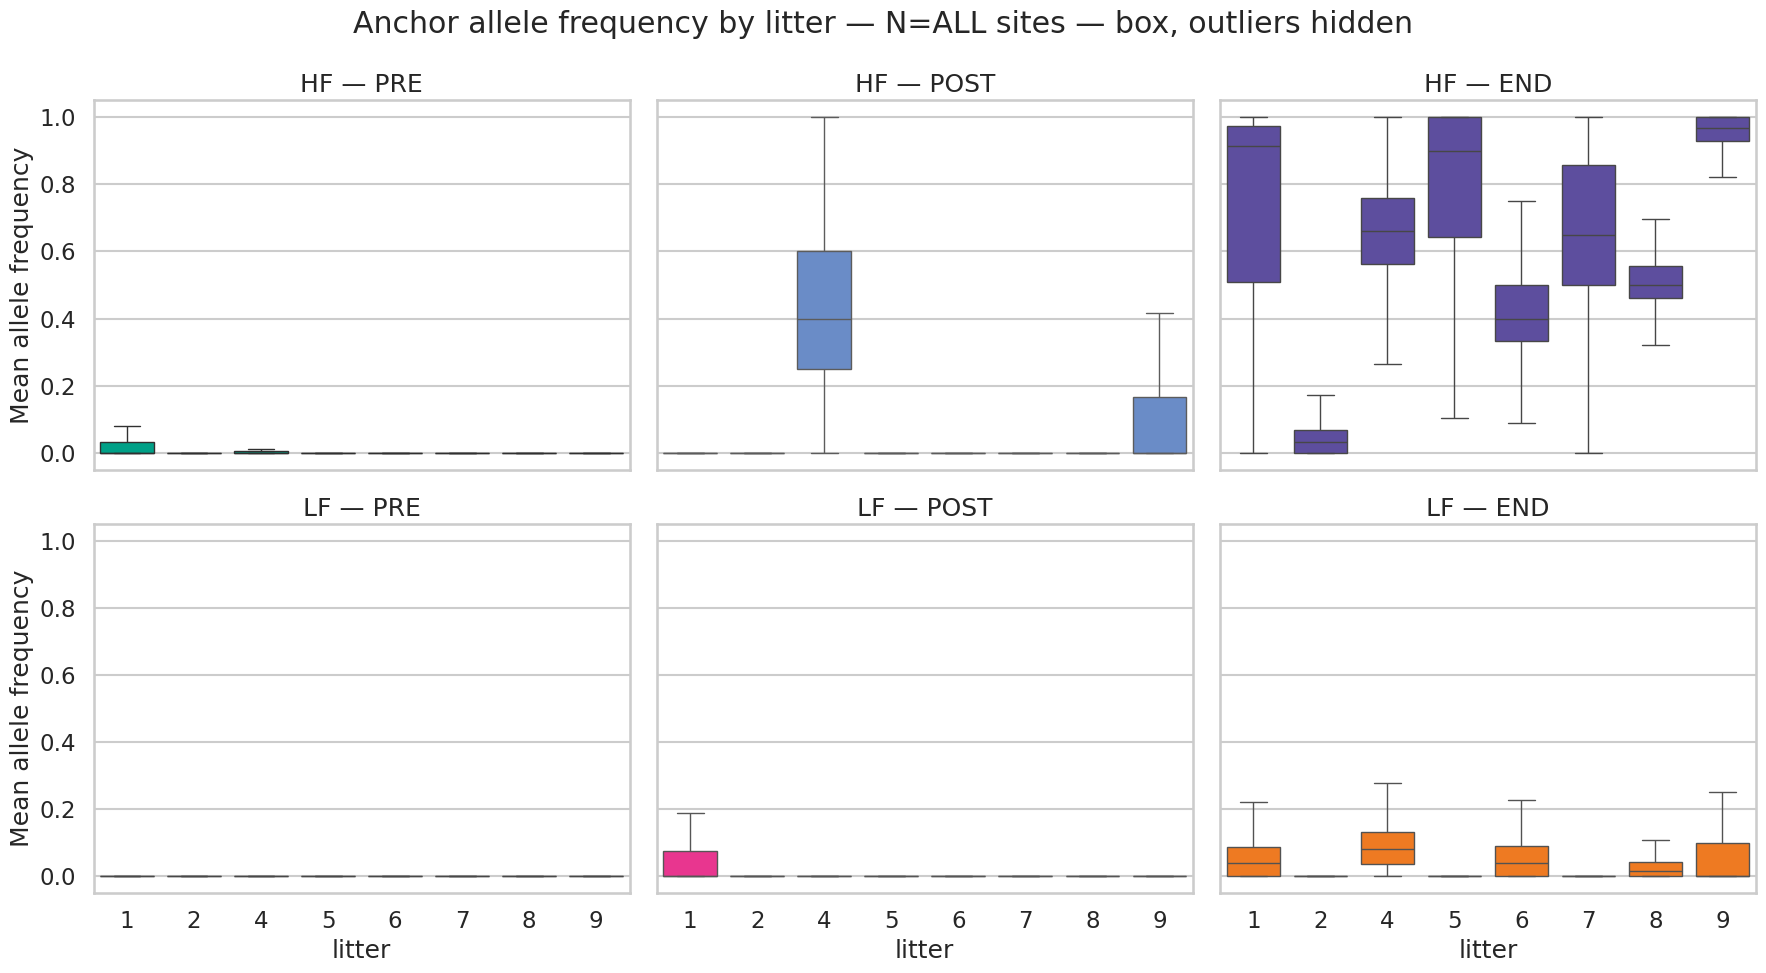

In [11]:
make_figure(means, df, "all", show_outliers=False, save=True)
plt.show()

n=2000: 2,000 sites, 8 litters, 96,000 values
[saved] figures/per_litter_box_n2000.pdf


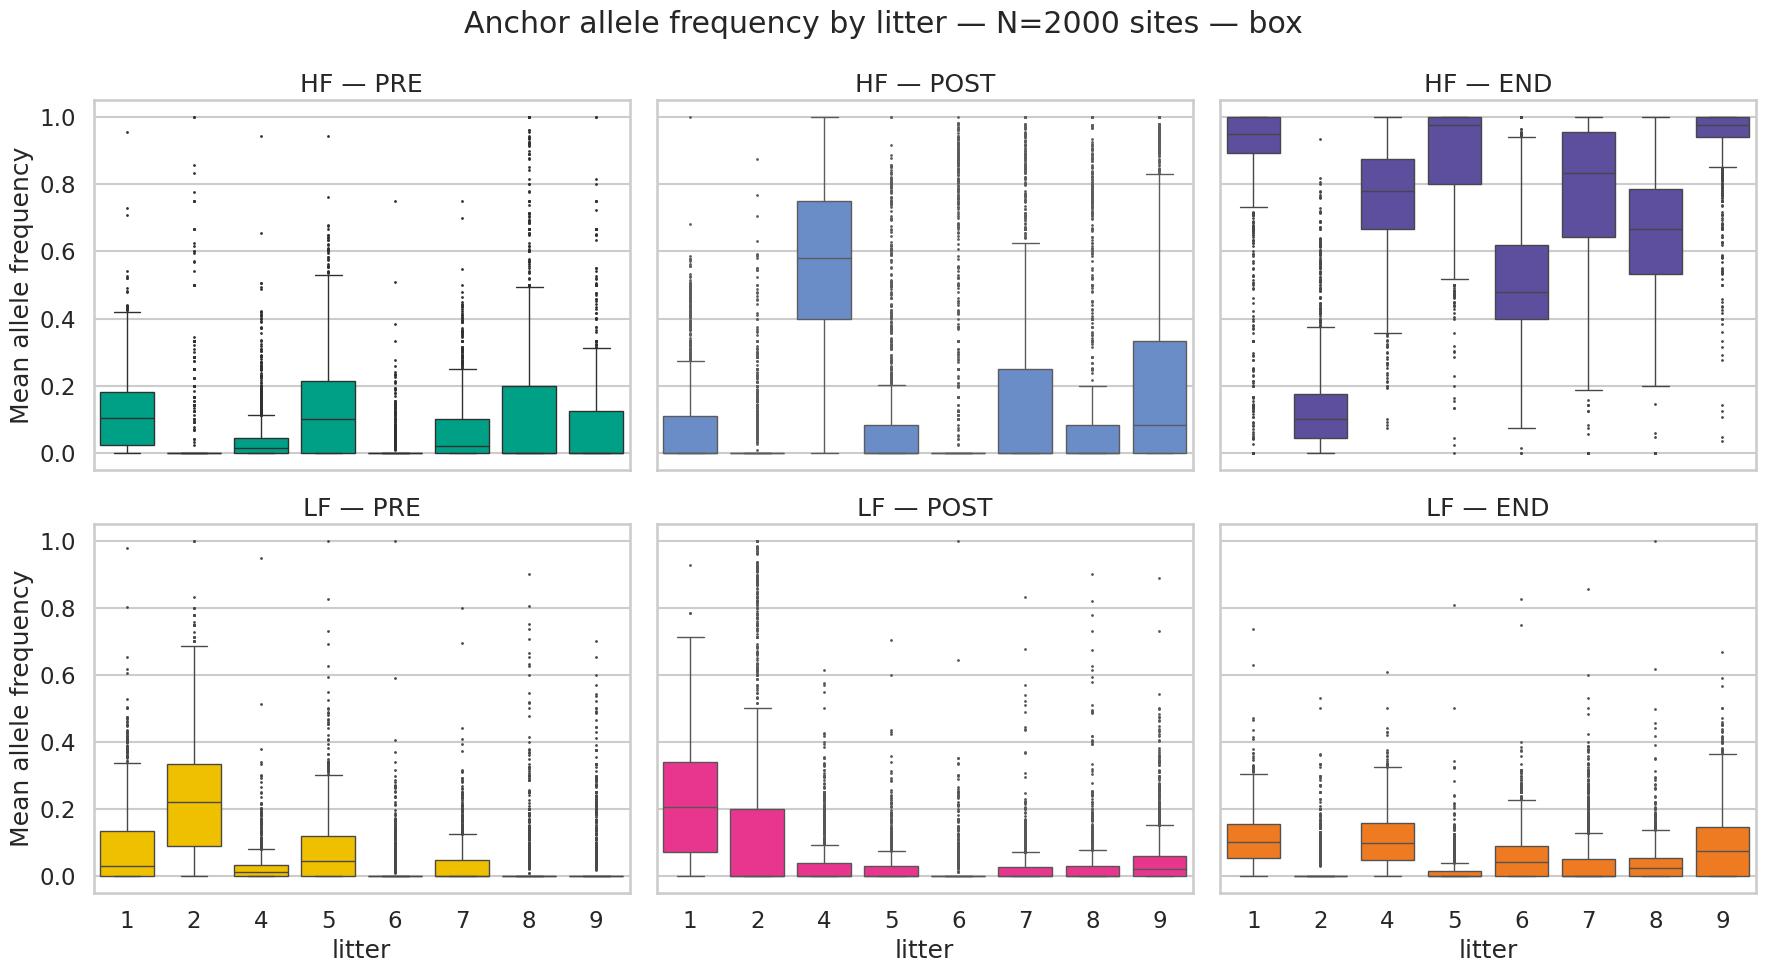

In [12]:
make_figure(means, df, 2000, show_outliers=True, save=True)
plt.show()

n=2000: 2,000 sites, 8 litters, 96,000 values
[saved] figures/per_litter_box_n2000_nofliers.pdf


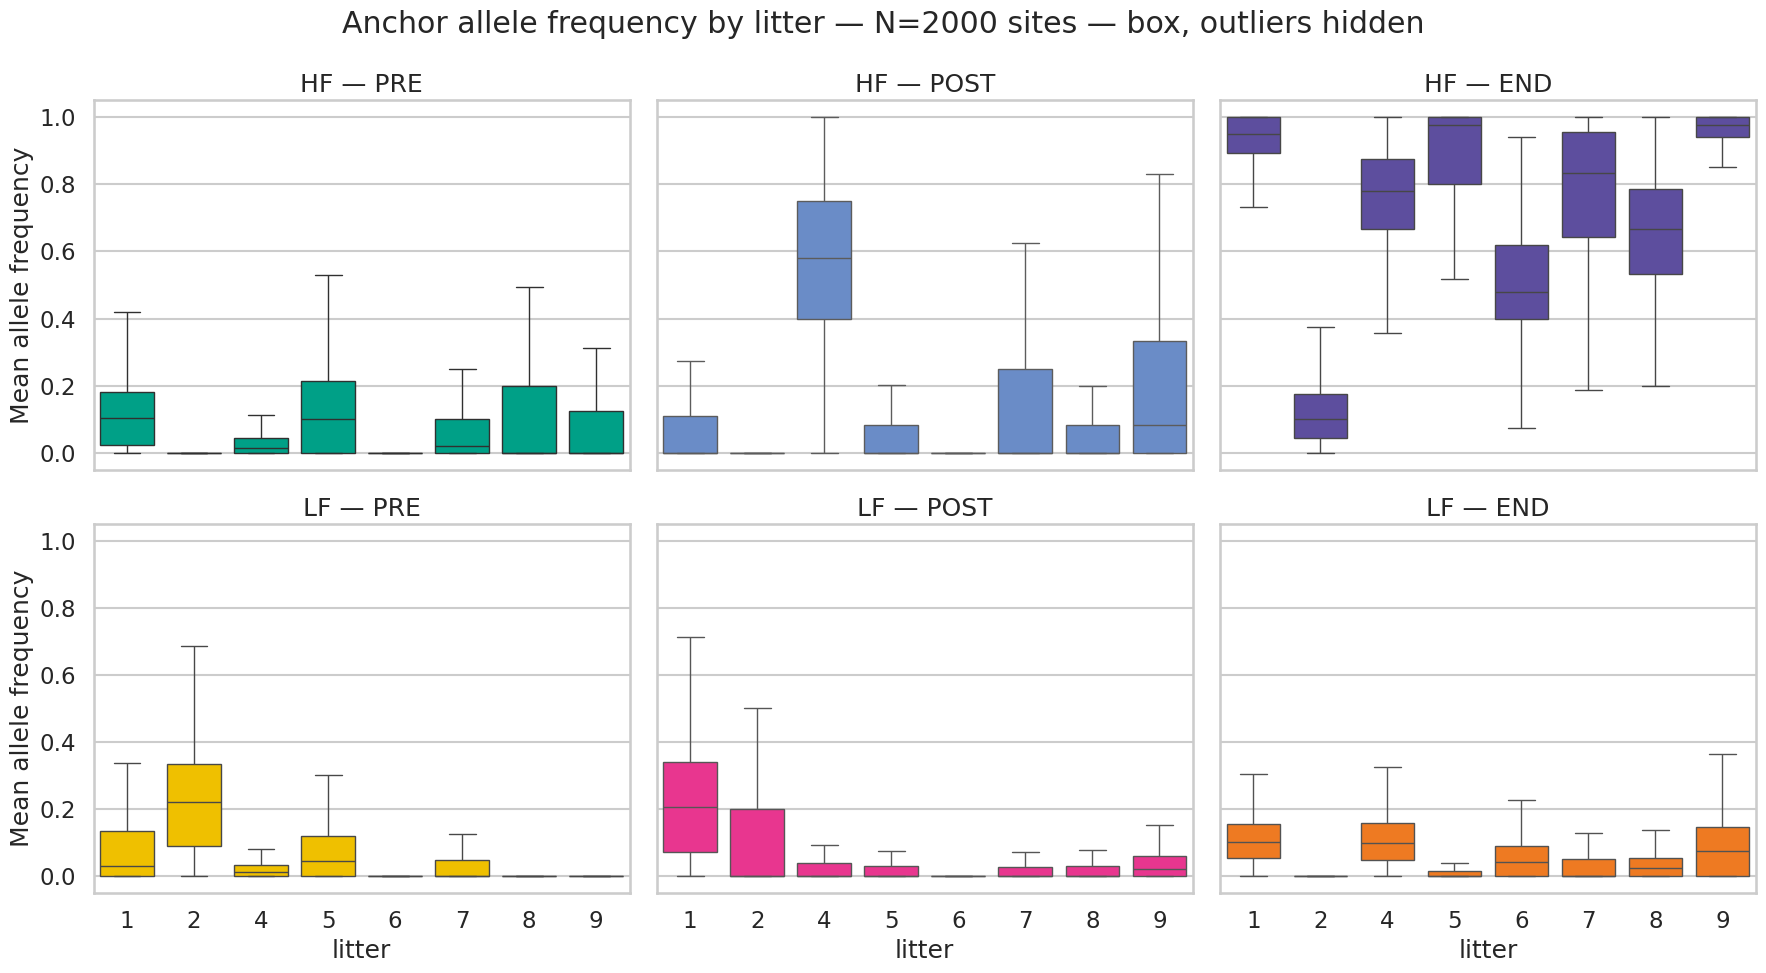

In [13]:
make_figure(means, df, 2000, show_outliers=False, save=True)
plt.show()

n=2000: 2,000 sites, 8 litters, 96,000 values
[saved] figures/per_litter_violin_n2000.pdf


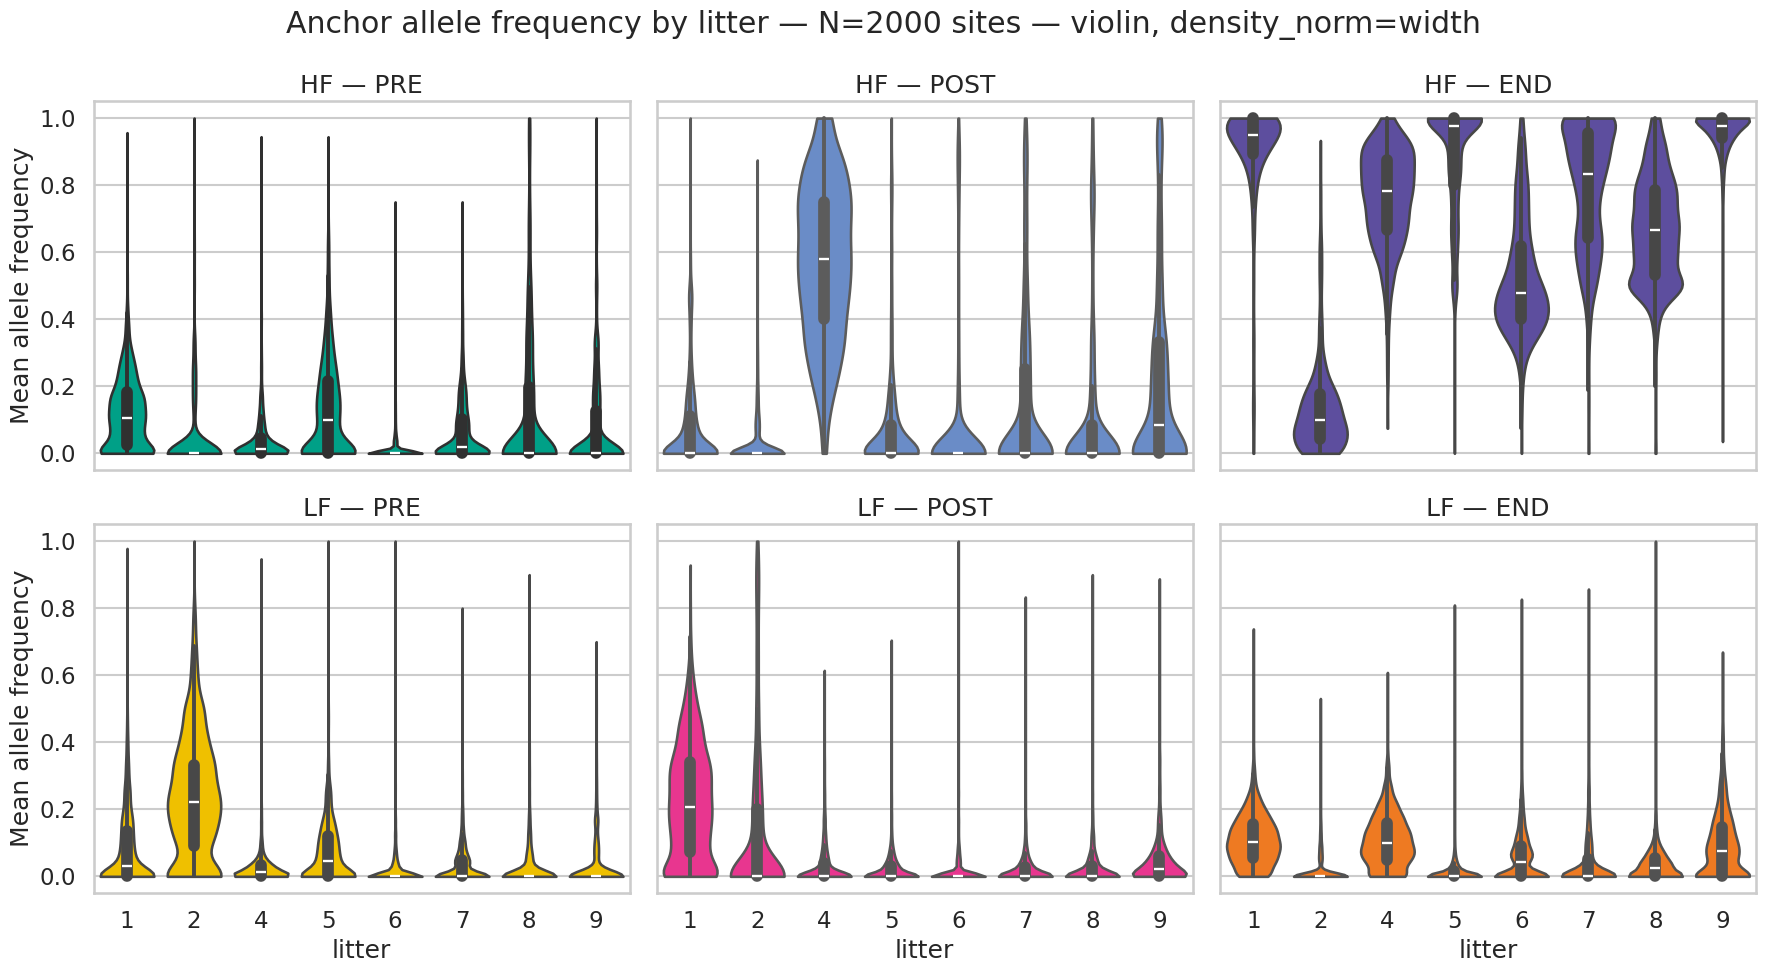

In [14]:
# violin
make_figure(means, df, 2000, kind="violin", save=True)
plt.show()

n=2000: 2,000 sites, 8 litters, 96,000 values
[saved] figures/per_litter_violin_n2000_count.pdf


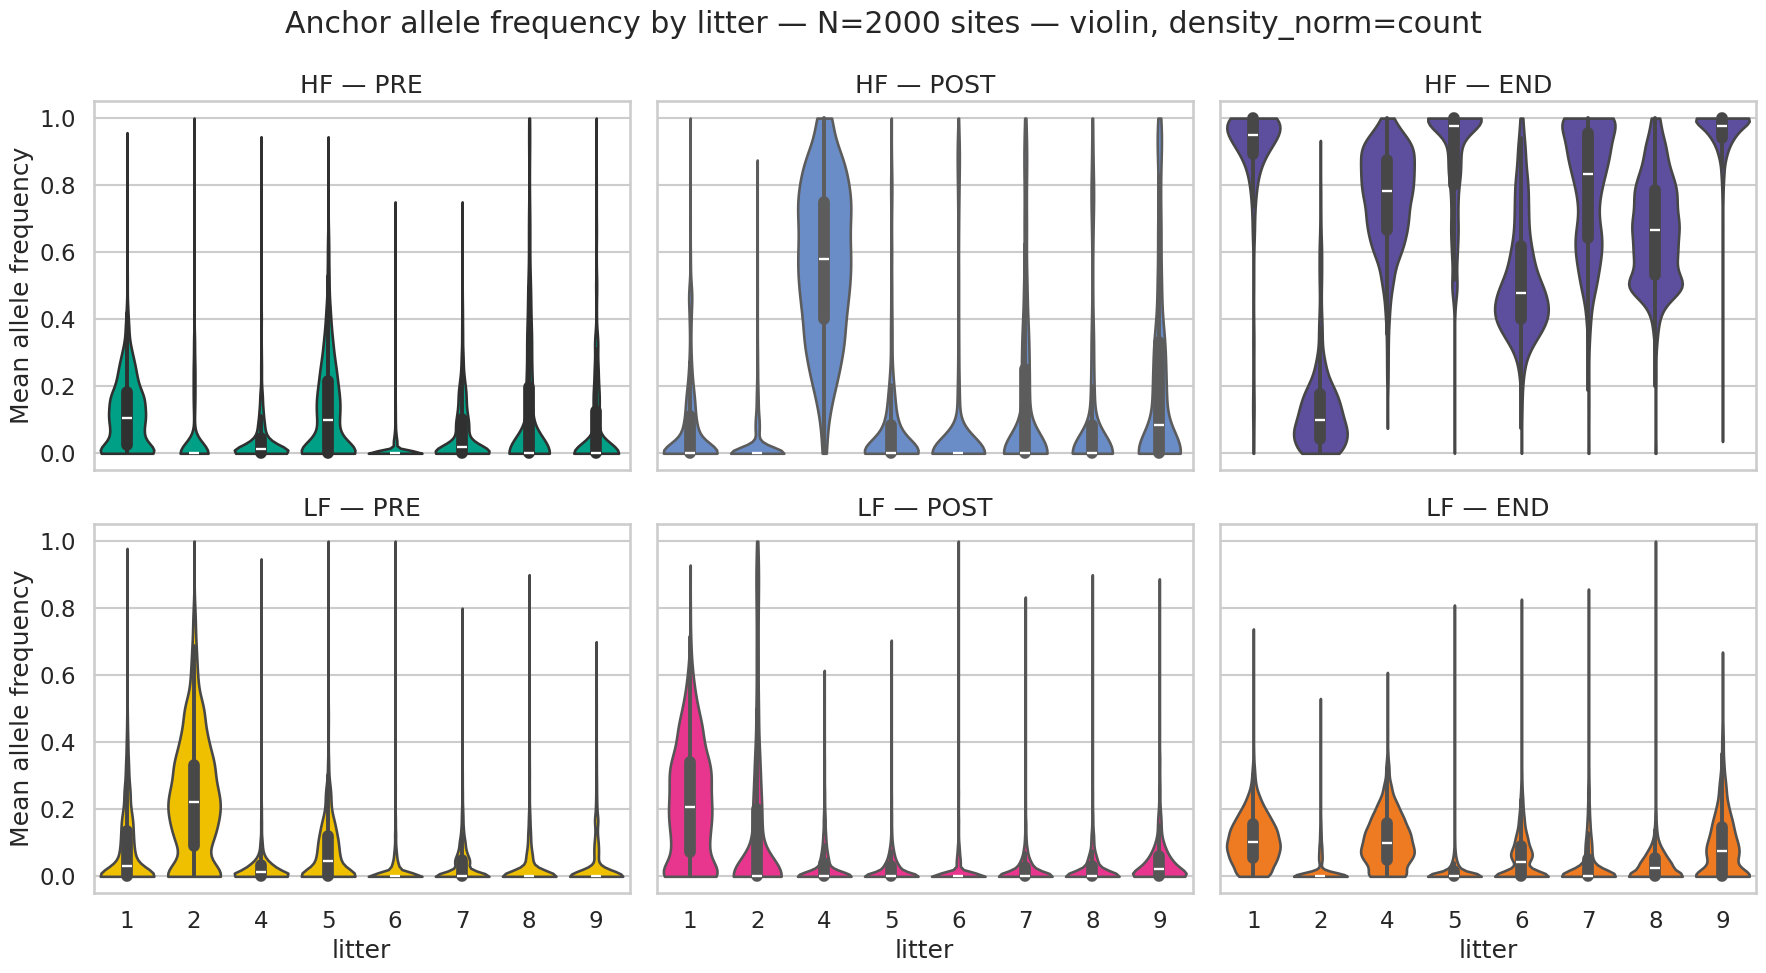

In [20]:
# violin
make_figure(means, df, 2000, kind="violin", save=True, density_norm="count")
plt.show()

n=ALL: 53,191 sites, 8 litters, 2,553,168 values
[saved] figures/per_litter_violin_nALL.pdf


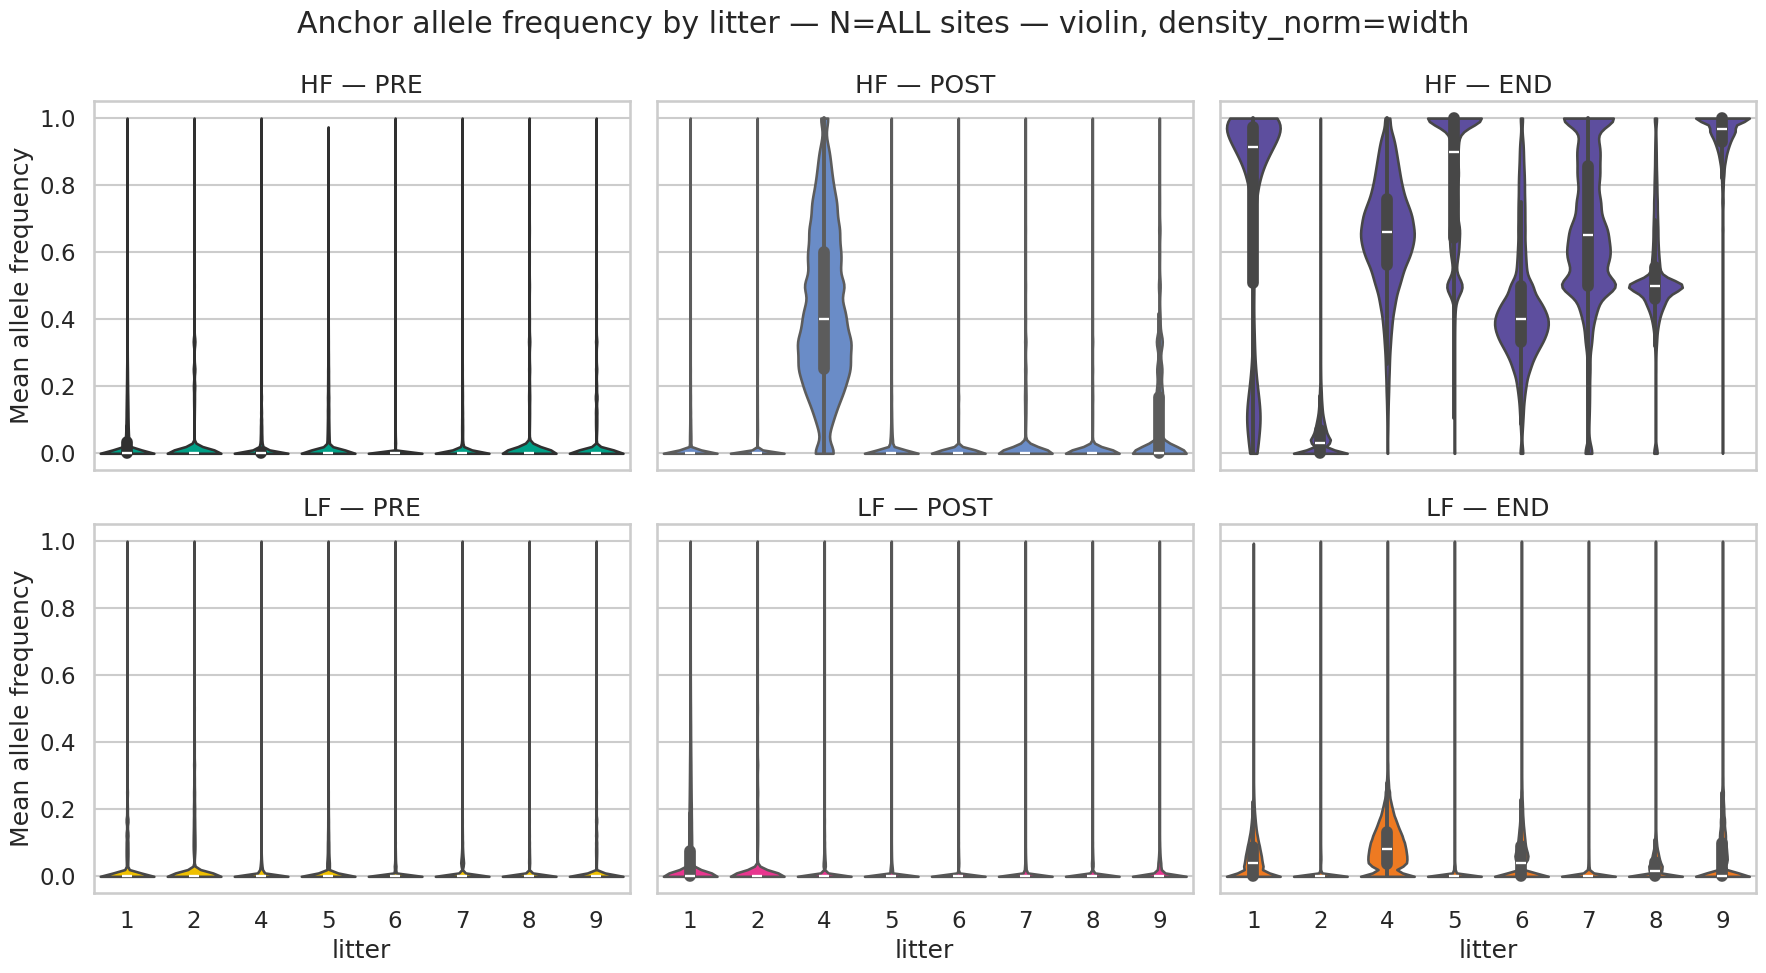

In [15]:
make_figure(means, df, "all", kind="violin", save=True)
plt.show()

## 5. Optional — sanity checks

Median frequency per (diet, timepoint), pooled over litters. HF should climb from PRE to END; LF should stay roughly flat. If LF climbs too, the anchor selection is picking up drift rather than a diet effect.


In [16]:
(means.groupby(["group", "time"], observed=True)["frequency"]
      .median().unstack("time")[TIMEPOINTS].round(3))

time,pre,post,end
group,,,
control,0.0,0.0,0.000
fat,0.0,0.0,0.617


In [17]:
# per-litter medians at END — litter 2 is the one to look at
(means[means["time"] == "end"]
     .groupby(["group", "replicate"], observed=True)["frequency"]
     .median().unstack("replicate").round(3))

replicate,1,2,4,5,6,7,8,9
group,,,,,,,,
control,0.038,0.000,0.083,0.0,0.038,0.00,0.016,0.000
fat,0.914,0.031,0.660,0.9,0.400,0.65,0.500,0.969


## 6. How many sites are actually in each box?

A site whose mice all lack coverage has a NaN litter mean and is dropped silently, so boxes do
not all hold the same number of sites. Run this for the same `n` you are publishing.

In [22]:
def sites_per_box(means, df, n=2000):
    """Sites actually drawn per box, i.e. after dropping all-NaN litter means."""
    sites = df[["contig", "position", "anchor_allele", "min_p_value"]].drop_duplicates()
    if str(n).lower() != "all":
        sites = sites.nsmallest(int(n), "min_p_value")

    plot_df = means.merge(
        sites[["contig", "position", "anchor_allele"]],
        on=["contig", "position", "anchor_allele"], how="inner",
    )

    tbl = (plot_df.dropna(subset=["frequency"])
                  .groupby(["group", "time", "replicate"], observed=True)
                  .size()
                  .unstack("replicate"))

    tbl = tbl.reindex([(g, t) for g in GROUP_ORDER for t in TIMEPOINTS])
    tbl.index = [f"{GROUP_LABELS.get(g, g)}-{t.upper()}" for g, t in tbl.index]
    tbl.columns.name = "litter"
    return tbl.astype("Int64")

tbl = sites_per_box(means, df, n=2000)
tbl

litter,1,2,4,5,6,7,8,9
HF-PRE,2000,1043,2000,2000,2000,2000,1507,1672
HF-POST,2000,1988,1982,2000,1962,1619,1497,1562
HF-END,1983,2000,2000,1986,2000,1979,2000,1994
LF-PRE,2000,1965,2000,2000,2000,2000,1999,1981
LF-POST,1999,1788,2000,2000,2000,2000,2000,2000
LF-END,2000,1999,2000,2000,1999,2000,2000,1999
